# Week 2 — Carrier Statistics & Transport

**Reading:** Streetman 3.3.1–3.3.4, 3.4.1–3.4.3, 3.5

**Goal:** Sweep plots for ni(T), EF vs doping, mobility vs doping, and conductivity vs doping — all importing from `mosfet_explorer`.

---

In [1]:
import sys
sys.path.insert(0, '../../src')

import numpy as np
import matplotlib.pyplot as plt

from mosfet_explorer import constants as C
from mosfet_explorer import carriers
from mosfet_explorer.plotting import apply_style, new_fig, label_axes, save_fig

apply_style()
print('mosfet_explorer loaded.')

mosfet_explorer loaded.


## Plot 1 — ni(T): Intrinsic Carrier Concentration vs Temperature

From mass action law (Streetman eq. 3-25):
$$n_i^2 = N_c N_v \exp\left(\frac{-E_g}{kT}\right)$$

- **Low T:** ni small, exponential suppression by Eg/kT
- **High T:** ni rises steeply as thermal energy bridges the bandgap
- **300K reference:** ni ≈ 1.5×10¹⁰ cm⁻³ for Si

Saved: ../../assets/week2_ni_vs_T.png


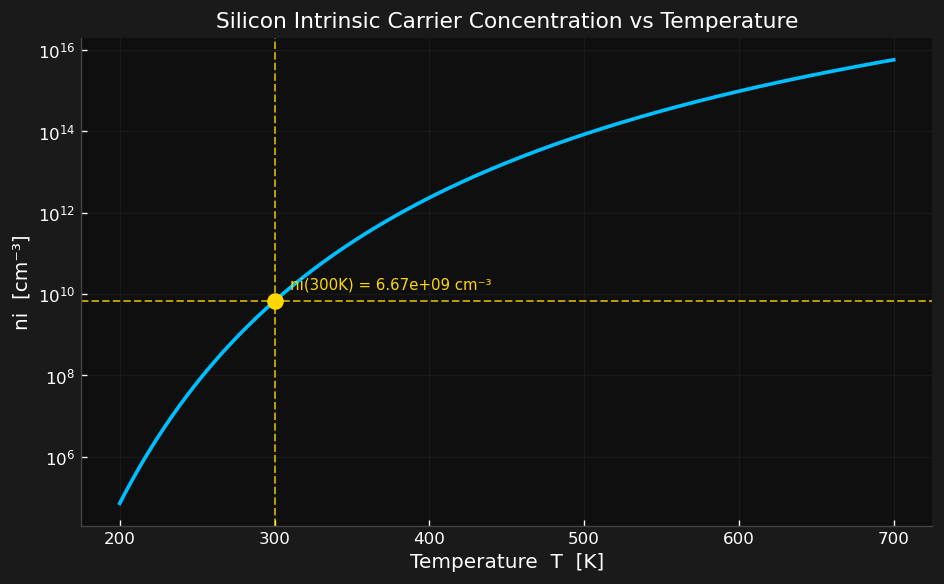

In [2]:
T_range = np.linspace(200, 700, 500)
ni_vals = np.array([carriers.ni(T) for T in T_range])

fig, ax = new_fig(figsize=(8, 5))

ax.semilogy(T_range, ni_vals, color='#00bfff', linewidth=2.2)

ni_300 = carriers.ni(300)
ax.axvline(300, color='#ffd700', linestyle='--', linewidth=1.2, alpha=0.7)
ax.axhline(ni_300, color='#ffd700', linestyle='--', linewidth=1.2, alpha=0.7)
ax.scatter([300], [ni_300], color='#ffd700', s=80, zorder=5)
ax.text(310, ni_300 * 2, f'ni(300K) = {ni_300:.2e} cm\u207b\u00b3', color='#ffd700', fontsize=9)

label_axes(ax,
    title='Silicon Intrinsic Carrier Concentration vs Temperature',
    xlabel='Temperature  T  [K]',
    ylabel='ni  [cm\u207b\u00b3]'
)
save_fig(fig, '../../assets/week2_ni_vs_T.png')
plt.show()

## Plot 2 — Fermi Level vs Doping Concentration

From Streetman eq. 3-23:
$$E_F - E_i = kT \ln\left(\frac{n_0}{n_i}\right)$$

- n-type: EF moves toward Ec as Nd increases
- p-type: EF moves toward Ev as Na increases
- At Nd = ni: EF ≈ Ei (intrinsic crossover)

Saved: ../../assets/week2_EF_vs_doping.png


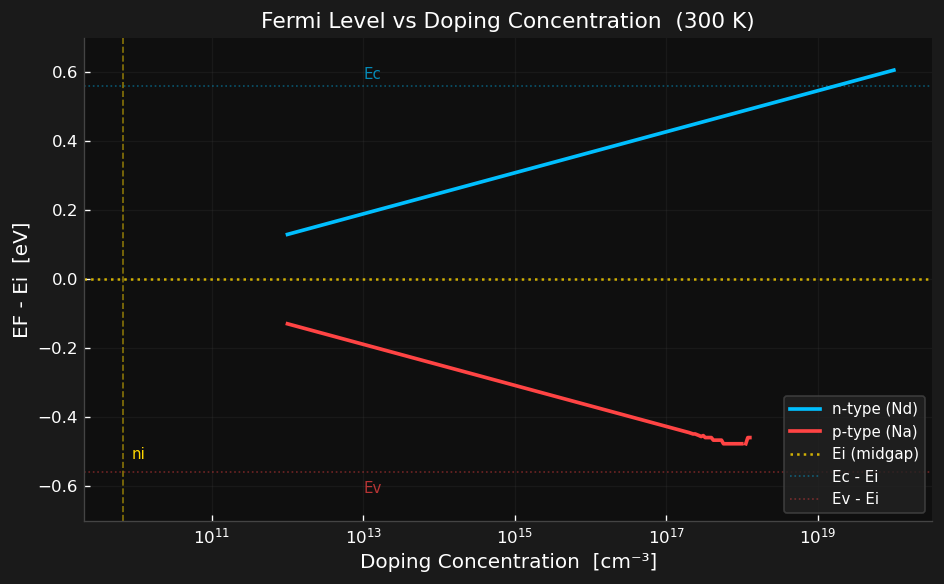

In [4]:
N_range = np.logspace(12, 20, 300)

EF_ntype = np.array([carriers.fermi_level(Nd=N) for N in N_range])
EF_ptype = np.array([carriers.fermi_level(Na=N) for N in N_range])

fig, ax = new_fig(figsize=(8, 5))

ax.semilogx(N_range, EF_ntype, color='#00bfff', linewidth=2.2, label='n-type (Nd)')
ax.semilogx(N_range, EF_ptype, color='#ff4444', linewidth=2.2, label='p-type (Na)')

ax.axhline(0,        color='#ffd700', linestyle=':', linewidth=1.5, alpha=0.8, label='Ei (midgap)')
ax.axhline( C.E_g/2, color='#00bfff', linestyle=':', linewidth=1.0, alpha=0.4, label='Ec - Ei')
ax.axhline(-C.E_g/2, color='#ff4444', linestyle=':', linewidth=1.0, alpha=0.4, label='Ev - Ei')
ax.axvline(carriers.ni(300), color='#ffd700', linestyle='--', linewidth=1, alpha=0.5)
ax.text(carriers.ni(300)*1.3, -0.52, 'ni', color='#ffd700', fontsize=9)
ax.text(1e13,  0.58, 'Ec', color='#00bfff', fontsize=9, alpha=0.7)
ax.text(1e13, -0.62, 'Ev', color='#ff4444', fontsize=9, alpha=0.7)
ax.set_ylim(-0.7, 0.7)

label_axes(ax,
    title='Fermi Level vs Doping Concentration  (300 K)',
    xlabel='Doping Concentration  [cm\u207b\u00b3]',
    ylabel='EF - Ei  [eV]',
    legend=True
)
save_fig(fig, '../../assets/week2_EF_vs_doping.png')
plt.show()

## Plot 3 — Mobility vs Doping Concentration

From Streetman 3.4.3 — two competing scattering mechanisms via Matthiessen's rule:
$$\frac{1}{\mu} = \frac{1}{\mu_\text{lattice}} + \frac{1}{\mu_\text{impurity}}$$

- At low doping: lattice scattering dominates → flat plateau
- At high doping: impurity scattering dominates → mobility falls
- µn > µp at all doping levels (electrons have lower effective mass)

Saved: ../../assets/week2_mobility_vs_doping.png


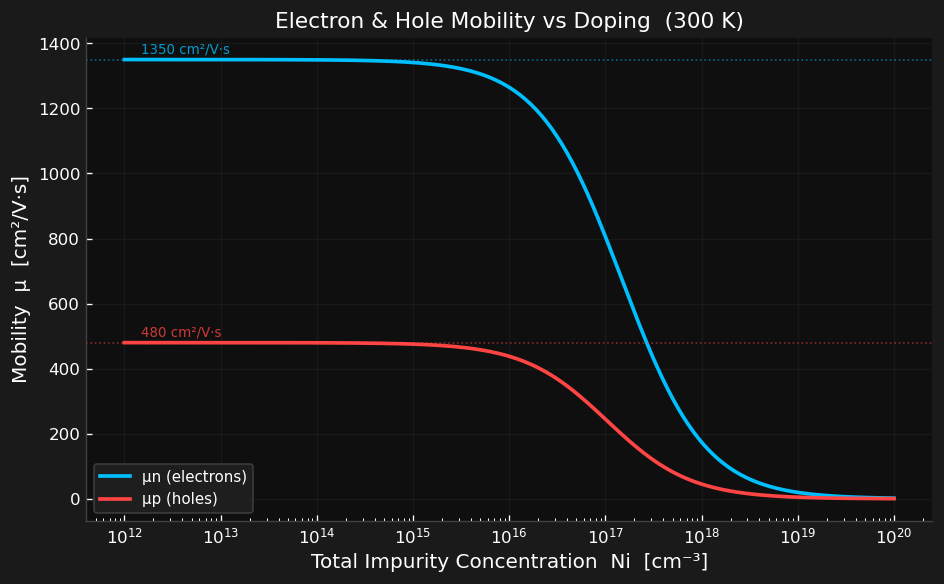

In [5]:
N_range = np.logspace(12, 20, 300)

mu_n_vals = np.array([carriers.mobility_n(T=300, N_I=N) for N in N_range])
mu_p_vals = np.array([carriers.mobility_p(T=300, N_I=N) for N in N_range])

fig, ax = new_fig(figsize=(8, 5))

ax.semilogx(N_range, mu_n_vals, color='#00bfff', linewidth=2.2, label='\u03bcn (electrons)')
ax.semilogx(N_range, mu_p_vals, color='#ff4444', linewidth=2.2, label='\u03bcp (holes)')

ax.axhline(C.mu_n_300, color='#00bfff', linestyle=':', linewidth=1, alpha=0.5)
ax.axhline(C.mu_p_300, color='#ff4444', linestyle=':', linewidth=1, alpha=0.5)
ax.text(1.5e12, C.mu_n_300 + 20, f'{C.mu_n_300} cm\u00b2/V\u00b7s', color='#00bfff', fontsize=8, alpha=0.8)
ax.text(1.5e12, C.mu_p_300 + 20, f'{C.mu_p_300} cm\u00b2/V\u00b7s', color='#ff4444', fontsize=8, alpha=0.8)

label_axes(ax,
    title='Electron & Hole Mobility vs Doping  (300 K)',
    xlabel='Total Impurity Concentration  Ni  [cm\u207b\u00b3]',
    ylabel='Mobility  \u03bc  [cm\u00b2/V\u00b7s]',
    legend=True
)
save_fig(fig, '../../assets/week2_mobility_vs_doping.png')
plt.show()

## Plot 4 — Conductivity & Resistivity vs Doping

From Streetman eq. 3-40 (equation 8 from notes):
$$\sigma = q(n\mu_n + p\mu_p)$$

- At low doping: both n and µ are small → low conductivity
- At high doping: n ≈ Nd rises fast, µ falls — conductivity still increases overall
- Resistivity is the inverse: ρ = 1/σ

Saved: ../../assets/week2_conductivity_vs_doping.png


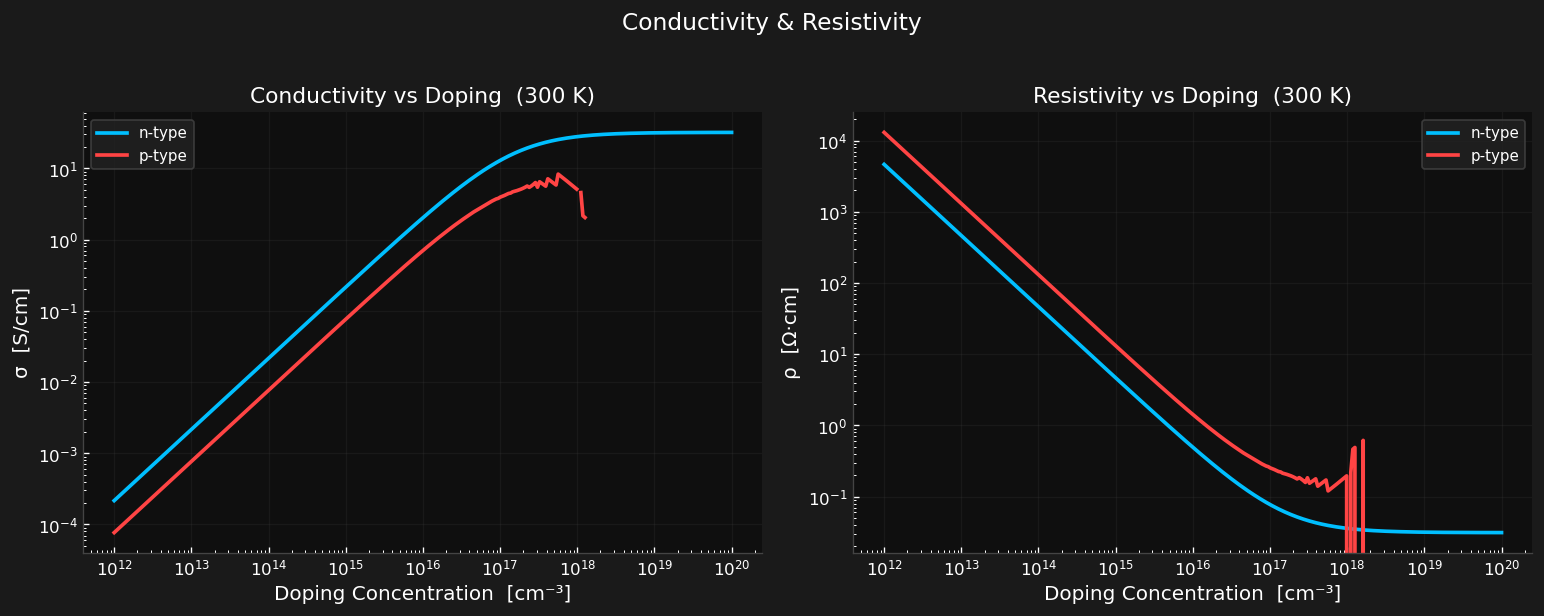

In [6]:
N_range = np.logspace(12, 20, 300)

sigma_n = np.array([carriers.conductivity(Nd=N) for N in N_range])
sigma_p = np.array([carriers.conductivity(Na=N) for N in N_range])
rho_n   = 1.0 / sigma_n
rho_p   = 1.0 / sigma_p

fig, axes = new_fig(1, 2, figsize=(13, 5))

axes[0].loglog(N_range, sigma_n, color='#00bfff', linewidth=2.2, label='n-type')
axes[0].loglog(N_range, sigma_p, color='#ff4444', linewidth=2.2, label='p-type')
label_axes(axes[0],
    title='Conductivity vs Doping  (300 K)',
    xlabel='Doping Concentration  [cm\u207b\u00b3]',
    ylabel='\u03c3  [S/cm]',
    legend=True
)

axes[1].loglog(N_range, rho_n, color='#00bfff', linewidth=2.2, label='n-type')
axes[1].loglog(N_range, rho_p, color='#ff4444', linewidth=2.2, label='p-type')
label_axes(axes[1],
    title='Resistivity vs Doping  (300 K)',
    xlabel='Doping Concentration  [cm\u207b\u00b3]',
    ylabel='\u03c1  [\u03a9\u00b7cm]',
    legend=True
)

plt.suptitle('Conductivity & Resistivity', fontsize=14, y=1.02)
save_fig(fig, '../../assets/week2_conductivity_vs_doping.png')
plt.show()

## Sanity Checks

In [7]:
print('=== Sanity Checks ===')

# 1. Mass action law
n, p = carriers.carrier_concentrations(Nd=1e15)
ni_val = carriers.ni(300)
print(f'np / ni\u00b2         = {(n*p)/ni_val**2:.8f}   (should be 1.0)')

# 2. Extrinsic regime: n ≈ Nd
Nd_test = 1e17
n, p = carriers.carrier_concentrations(Nd=Nd_test)
print(f'n / Nd (1e17)    = {n/Nd_test:.6f}   (should be ~1.0)')

# 3. EF direction
EF_n = carriers.fermi_level(Nd=1e16)
EF_p = carriers.fermi_level(Na=1e16)
print(f'EF - Ei (n-type) = {EF_n:+.4f} eV   (should be > 0)')
print(f'EF - Ei (p-type) = {EF_p:+.4f} eV   (should be < 0)')

# 4. µn > µp at all doping levels
for N in [1e14, 1e17, 1e20]:
    mn = carriers.mobility_n(N_I=N)
    mp = carriers.mobility_p(N_I=N)
    ok = '\u2713' if mn > mp else '\u2717'
    print(f'{ok} \u03bcn={mn:.0f} > \u03bcp={mp:.0f}  at N={N:.0e} cm\u207b\u00b3')

# 5. sigma * rho = 1
sig = carriers.conductivity(Nd=1e16)
rho = carriers.resistivity(Nd=1e16)
print(f'\u03c3 \u00d7 \u03c1            = {sig*rho:.8f}   (should be 1.0)')

=== Sanity Checks ===
np / ni²         = 1.00000000   (should be 1.0)
n / Nd (1e17)    = 1.000000   (should be ~1.0)
EF - Ei (n-type) = +0.3676 eV   (should be > 0)
EF - Ei (p-type) = -0.3676 eV   (should be < 0)
✓ μn=1349 > μp=480  at N=1e+14 cm⁻³
✓ μn=806 > μp=245  at N=1e+17 cm⁻³
✓ μn=2 > μp=0  at N=1e+20 cm⁻³
σ × ρ            = 1.00000000   (should be 1.0)
